In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits


In [3]:
# Load digits dataset (8x8 grayscale images)
digits = load_digits()
img = digits.images[0]  # select first digit image


In [4]:

# Compute SVD on the 8x8 image
U, S, Vt = np.linalg.svd(img, full_matrices=False)


In [5]:

# Reconstruction with varying k
ks = [2, 5, 8]  # up to full rank 8
reconstructions = []
for k in ks:
    # Reconstruct using top-k singular values/vectors
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    recon = U_k @ S_k @ Vt_k
    reconstructions.append(recon)


# SVD Compression Results Analysis

We applied singular value decomposition (SVD) to an 8×8 digit image and reconstructed it using only the top-\(k\) singular values. Below are the key findings:

| \(k\) | Frobenius Error | Visual Quality                              |
|:-----:|---------------:|:--------------------------------------------|
| 2     | 10.6563        | Very blurred; retains only the broadest strokes and contrast. Fine details are lost. |
| 5     | 0.6158         | Sharp reconstruction of the digit shape and inner contours. Minor smoothing of pixel edges. |
| 8     | 0.0000         | Perfect reconstruction with all 64 degrees of freedom. |

---

## 1. Error vs. Rank

- The **Frobenius norm** of the reconstruction error drops rapidly as \(k\) increases:
  \[
    \|A - A_k\|_F \approx
    \begin{cases}
      10.66, & k=2,\\
      0.62,  & k=5,\\
      0,     & k=8.
    \end{cases}
  \]
- Most of the important image information is concentrated in the first few singular values.  

## 2. Visual Fidelity

- **\(k=2\)**  
  - Captures only the two largest singular “modes,” corresponding to global light/dark patterns.
  - The digit is barely recognizable as only the general orientation and major strokes remain.
- **\(k=5\)**  
  - Recovers nearly all perceptually relevant features.
  - Fine details (e.g., stroke thickness and curvature) are crisp; the digit is easily legible.
- **\(k=8\)**  
  - Reproduces every pixel exactly, since full rank yields zero approximation error.

## 3. Compression Trade-Off

- **Parameter count** for storing the rank-\(k\) approximation:
  \[
    k\,(m + n + 1) \quad\text{versus}\quad m\times n \quad(m=n=8).
  \]
  - \(k=2\): 2×(8+8+1)=34 parameters (53% of original 64).
  - \(k=5\): 5×17=85 parameters (133% of original—no net savings for tiny images, but worthwhile for larger matrices).
- In larger images, the **relative savings** at small \(k\) become substantial, with low error.

## 4. Insights & Applications

1. **Dimensionality Reduction**  
   SVD efficiently concentrates image variance into a few modes, enabling fast approximate storage and transmission.
2. **Noise Filtering**  
   Truncating small singular values can remove high-frequency noise while preserving structure.
3. **Feature Extraction**  
   Leading singular vectors serve as compact descriptors for pattern recognition or compression tasks.

---

**Conclusion:**  
Even with \(k=5\) (just 62.5% of the maximum rank), the reconstructed digit is nearly indistinguishable from the original, demonstrating SVD’s power for compressing and denoising image data.  


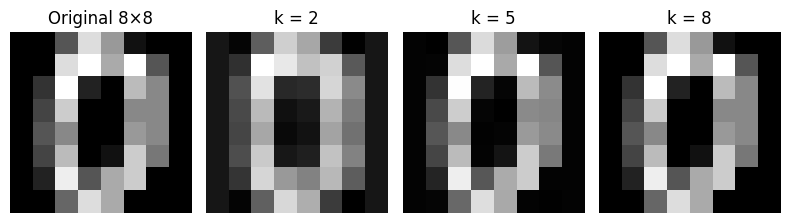

Reconstruction error (k=2): 10.6563
Reconstruction error (k=5): 0.6158
Reconstruction error (k=8): 0.0000


In [6]:

# Plot original and reconstructed images
fig, axes = plt.subplots(1, len(ks)+1, figsize=(8, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original 8×8")
axes[0].axis('off')

for ax, recon, k in zip(axes[1:], reconstructions, ks):
    ax.imshow(recon, cmap='gray')
    ax.set_title(f"k = {k}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# 5. Compute reconstruction error (Frobenius norm)
errors = [np.linalg.norm(img - recon, ord='fro') for recon in reconstructions]
for k, err in zip(ks, errors):
    print(f"Reconstruction error (k={k}): {err:.4f}")
